# Ingest experiment data

In [105]:
import lib.experiment_oop as exp
import joblib

# # GREEN
# dPaths = ["/media/DATA/MAK/GRISZ_02/AA0001",
#           "/media/DATA/MAK/GRISZ_03/AA0001",
#           "/media/DATA/MAK/GRISZ_05/AA0001",
# ]
dPaths = [r"C:\Data\Manoj Data\GRISZ_02\AA0001"]

# Create and load an experiment group
group = exp.ExperimentGroup(dPaths, format = 'MAK')
# drop rows with missing dB match
group.df = group.df[~group.df['dB'].isna()]
group.load_qcam_data()
# set all to same frame length
group.df = group.df[group.df['nFrames']==int(group.df.nFrames.mode()[0])]
# joblib.dump(group,'../data/cache/GRISZ_2-3-5_group_df.joblib')
# group = joblib.load('../data/cache/GRISZ_2-3-5_group_df.joblib')

In [ ]:
experiment_idx = 0

experiment = group.experiments[experiment_idx]
experiment

,qcam,dir,xsg,pulse,dB,treatment
1,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_40dB_10000msTotal_Fs250kHz,40,CTRL
2,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL
3,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_70dB_10000msTotal_Fs250kHz,70,CTRL
4,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_60dB_10000msTotal_Fs250kHz,60,CTRL
5,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL
...,...,...,...,...,...,...
85,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL
86,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_70dB_10000msTotal_Fs250kHz,70,CTRL
87,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_40dB_10000msTotal_Fs250kHz,40,CTRL
88,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,C:\Data\Manoj Data\GRISZ_02\AA0001,C:\Data\Manoj Data\GRISZ_02\AA0001\AA0001AAAA0...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL


c:\Users\SHY200\OneDrive - University of Pittsburgh\Documents\Python\pyFluo\src\lib\plotting.py:95: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


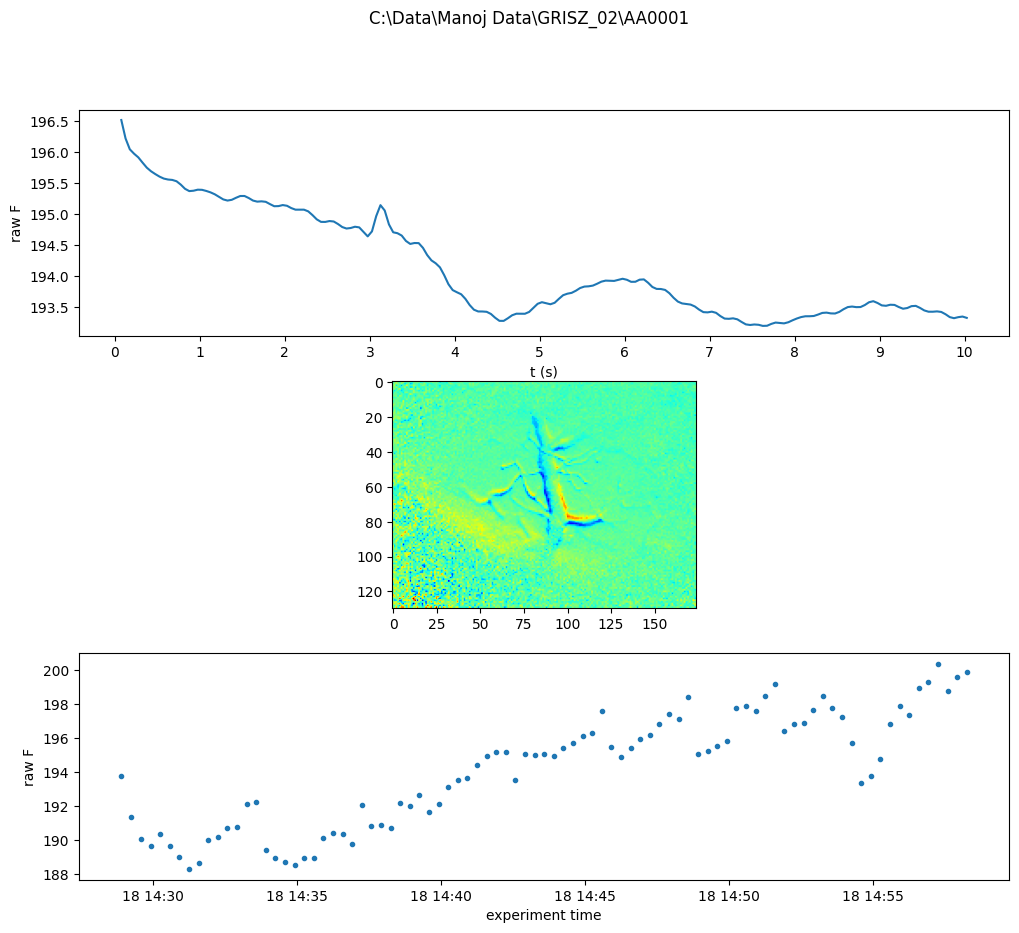

In [107]:
experiment.plot_experiment_overview()

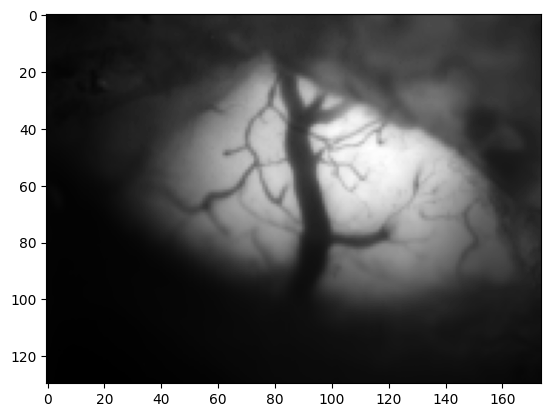

In [ ]:
from operator import itemgetter
import numpy as np
import matplotlib.pyplot as plt

dB = 80
qcam_dB = sorted(experiment.df.loc[experiment.df['dB'] == dB, 'qcam'].tolist())
rawF = np.array(itemgetter(*qcam_dB)(experiment.qcam2img))
plt.imshow(rawF.mean(axis=(0,-1)),'gray')

# Step-by-step hierarchical clustering


## Create ROI as bins that sweep across image:

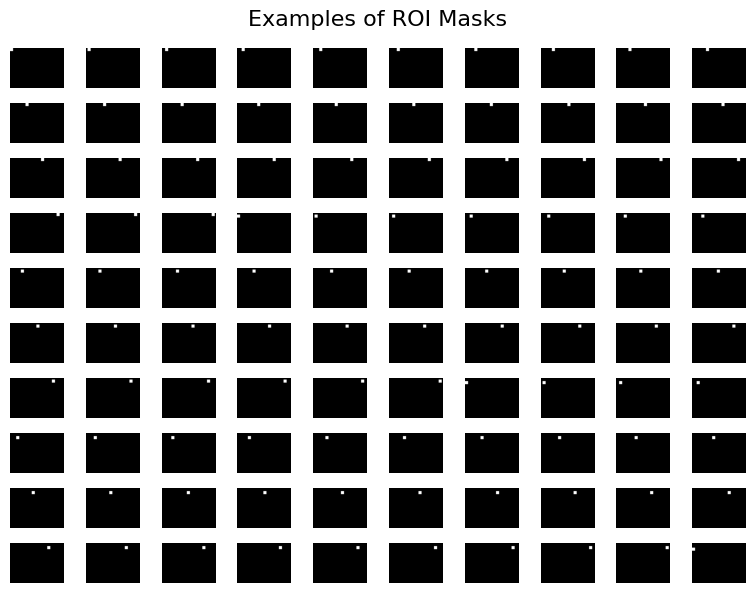

In [109]:
import lib.imgProcess as imgProcess

# qcam_idx = 5
# print(qcam_dB[qcam_idx])
# img_series = experiment.qcam2img[qcam_dB[qcam_idx]]

# Average across all files
img_series = np.array([experiment.qcam2img[key] for key in qcam_dB])

masks, x_roi, y_roi = imgProcess.get_roi_sweep_masks(img_series, roi_size = 10, shift = 5, plot_roi = (10, 10))

In [110]:
import lib.signalProcess as signalProcess

# apply to a given image series
roi_avg = signalProcess.get_avg_in_rois(img_series, masks)

Image array: (15, 130, 174, 200)
ROI fluorescence array: (15, 825, 200)


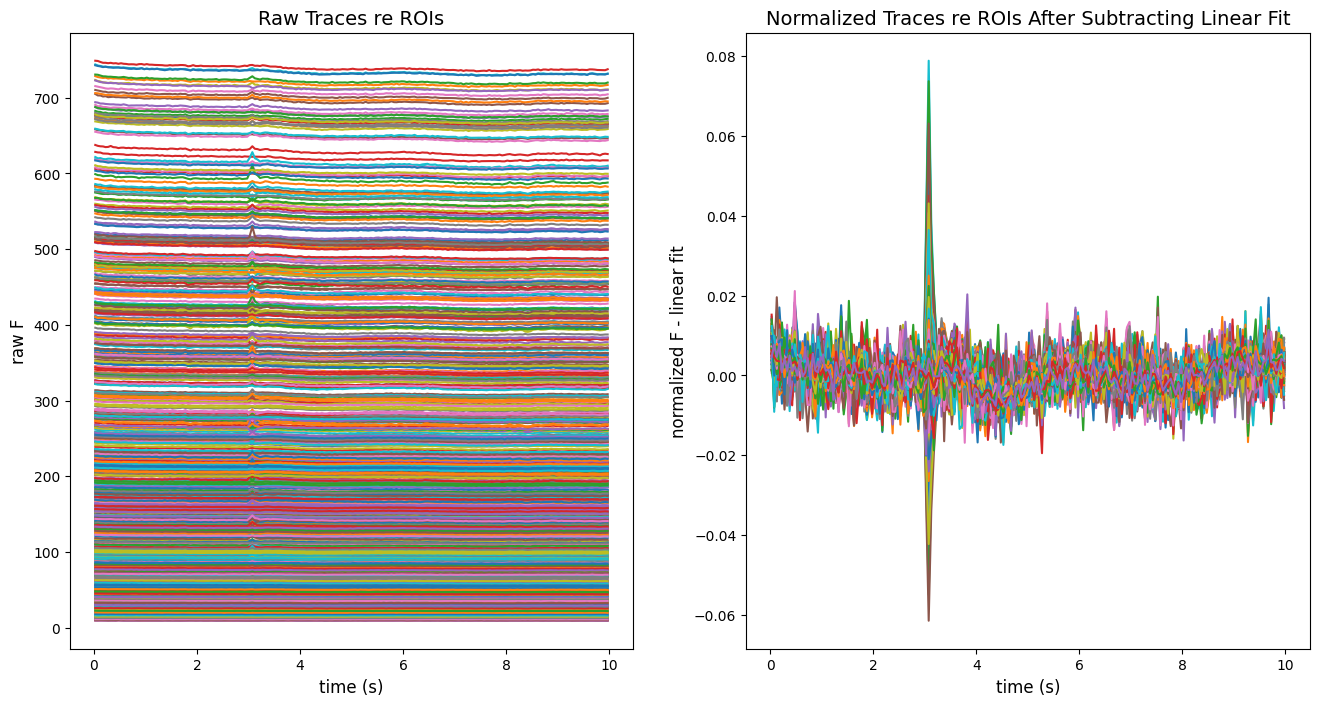

In [111]:
import lib.plotting as plotting
roi_avg_filt = plotting.plot_ROI_trace(roi_avg, normalize=True, plot_trace=True)

## Hierarchical clustering 

In [112]:
linkage_matrix = signalProcess.cluster_roi(roi_avg_filt)

# from scipy.cluster.hierarchy import fcluster
# n_clusters = 4
# cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')

Input data shape for clustering: (825, 200)


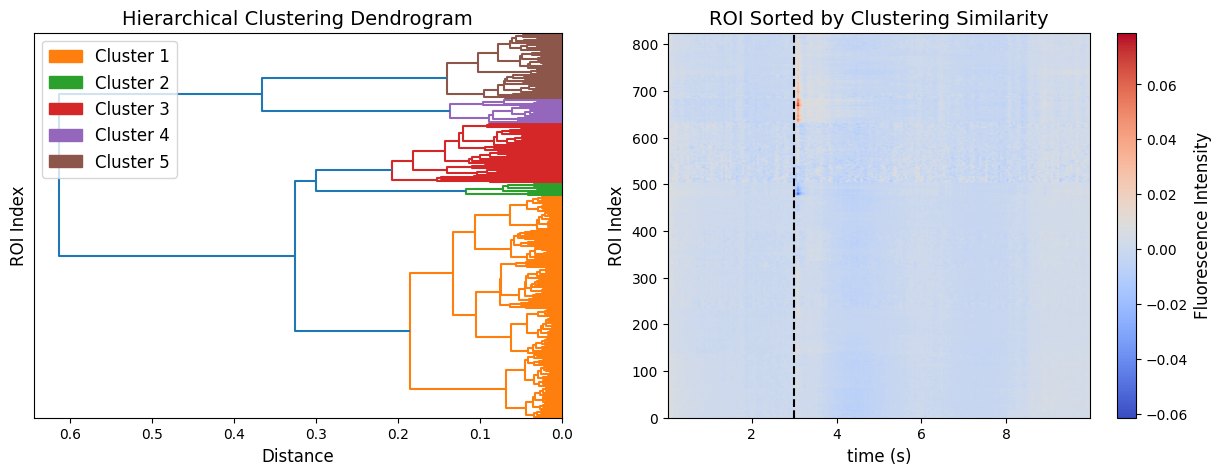

In [152]:
color_map, leaves_color_list, leaf_order = plotting.plot_hierarchical_cluster(linkage_matrix, roi_avg_filt, 
                                                                              color_threshold=0.4*max(linkage_matrix[:,2])
                                                                              # color_threshold=0.5
)

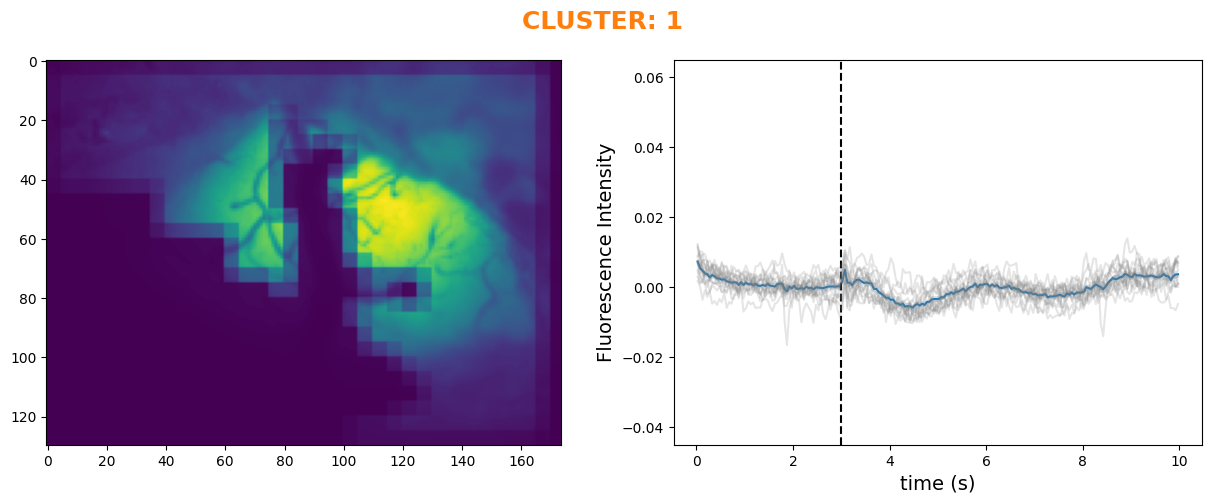

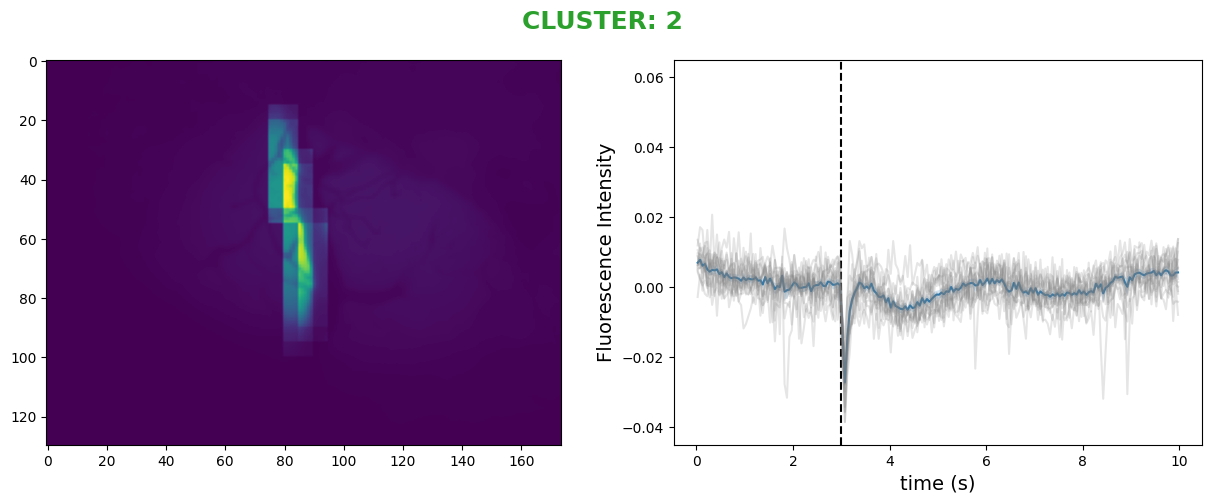

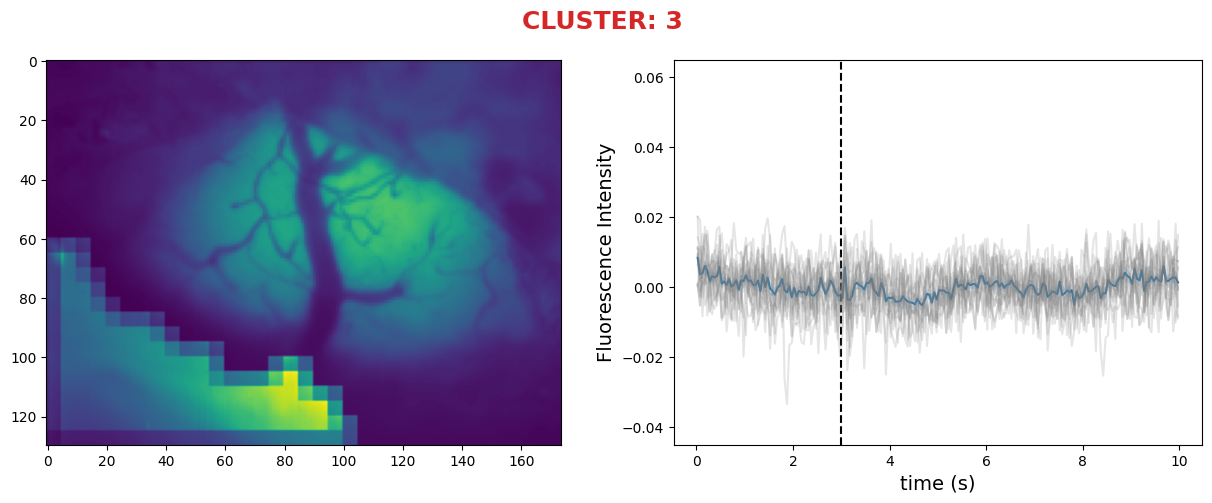

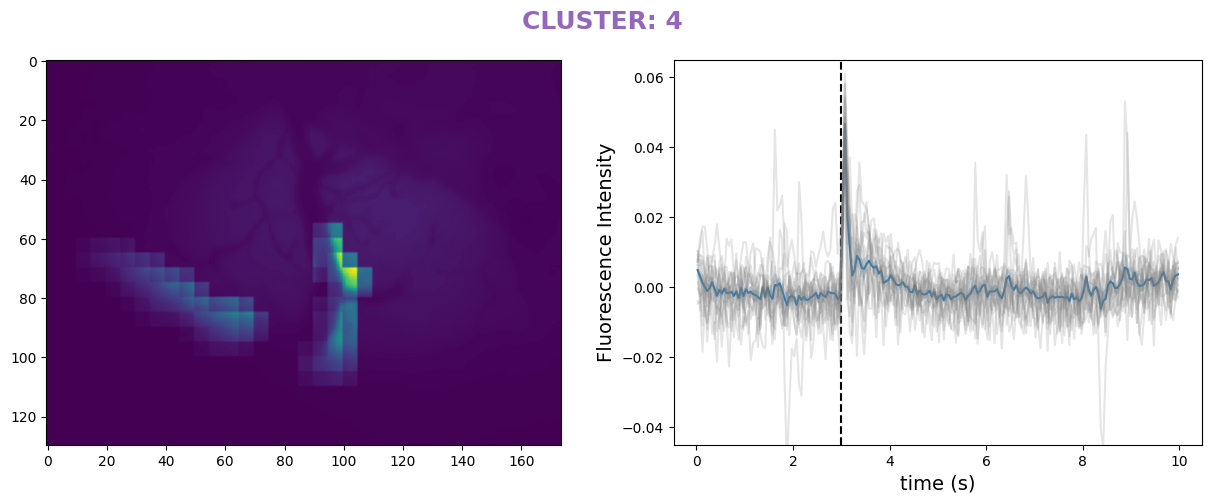

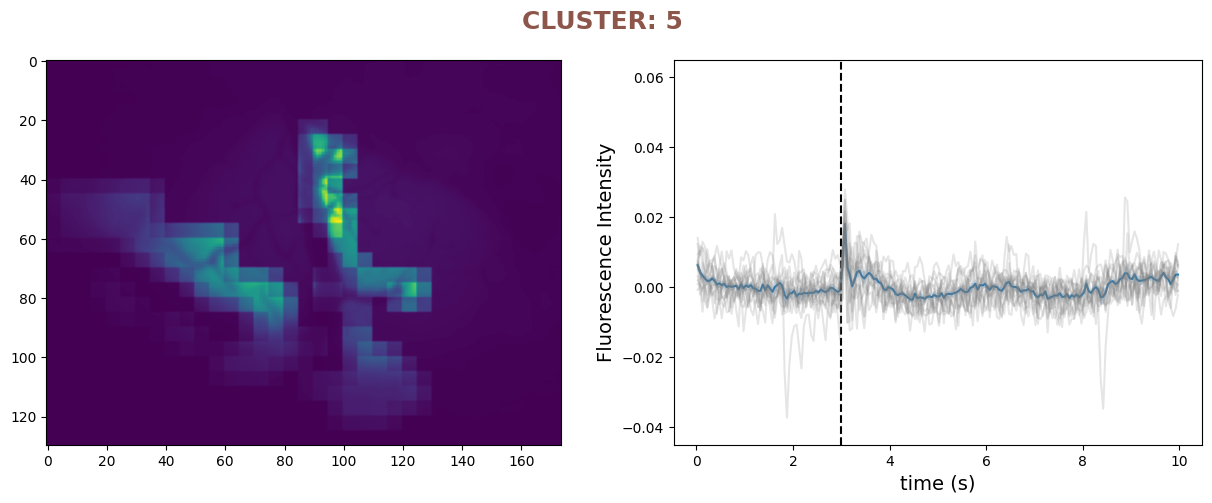

In [114]:
plotting.plot_cluster_roi(img_series, masks, roi_avg_filt, color_map, leaves_color_list, leaf_order, 
                          Yaxis_range=(-0.045, 0.065), plot_errBar=True, plot_traces=True)

# Hierarchical clustering: all-in-one

In [115]:
import lib.experiment_oop as exp
import joblib

# # GREEN
# dPaths = ["/media/DATA/MAK/GRISZ_02/AA0001",
#           "/media/DATA/MAK/GRISZ_03/AA0001",
#           "/media/DATA/MAK/GRISZ_05/AA0001",
# ]

dPaths = [r"C:\Data\Manoj Data\GRISZ_02\AA0001"]

# Create and load an experiment group
group = exp.ExperimentGroup(dPaths, format = 'MAK')
# drop rows with missing dB match
group.df = group.df[~group.df['dB'].isna()]
group.load_qcam_data()
# set all to same frame length
group.df = group.df[group.df['nFrames']==int(group.df.nFrames.mode()[0])]
# joblib.dump(group,'../data/cache/GRISZ_2-3-5_group_df.joblib')
# group = joblib.load('../data/cache/GRISZ_2-3-5_group_df.joblib')

# Specify animal ID and sound intensity to plot
experiment_idx = 0
dB = 80

experiment = group.experiments[experiment_idx]
qcam_dB = sorted(experiment.df.loc[experiment.df['dB'] == dB, 'qcam'].tolist())

Image array: (15, 130, 174, 200)
ROI fluorescence array: (15, 825, 200)
Input data shape for clustering: (825, 200)


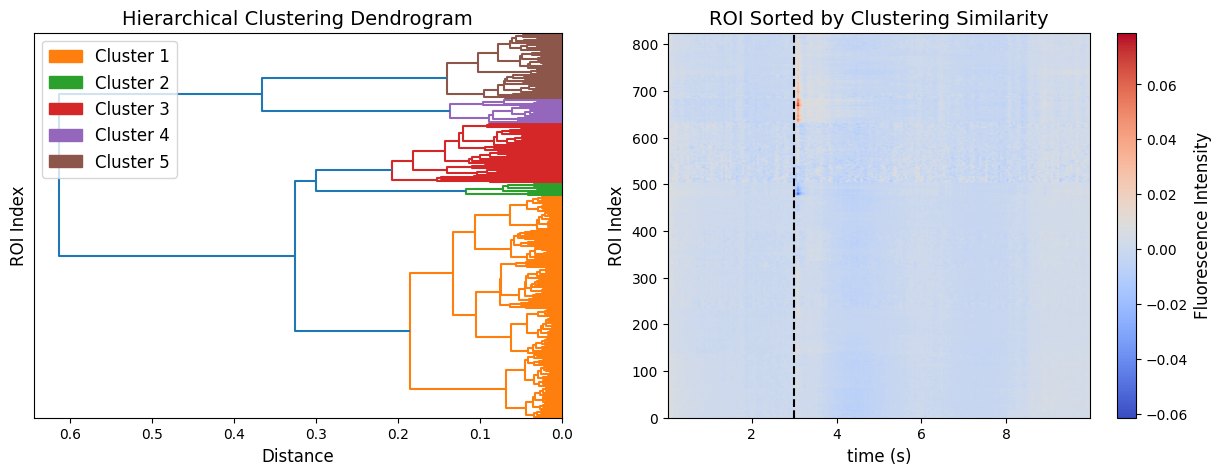

In [153]:
import numpy as np
import lib.imgProcess as imgProcess
import lib.signalProcess as signalProcess
import lib.plotting as plotting

# Only plot the 6th trial
# qcam_idx = 5
# print(qcam_dB[qcam_idx])
# img_series = experiment.qcam2img[qcam_dB[qcam_idx]]

# Average across all trials
img_series = np.array([experiment.qcam2img[key] for key in qcam_dB])

# Get series of sweeping ROIs
masks, x_roi, y_roi = imgProcess.get_roi_sweep_masks(img_series, roi_size = 10, shift = 5, plot_roi = None)
# masks, x_roi, y_roi = imgProcess.get_roi_sweep_masks(img_series, roi_size = 8, shift = 4, plot_roi = None)

# Get average fluorescence traces within ROIs
roi_avg = signalProcess.get_avg_in_rois(img_series, masks)

# Perform linear fit subtraction and normalization for average fluorescence traces
roi_avg_filt = plotting.plot_ROI_trace(roi_avg, normalize = True, plot_trace = False)

# Calculate linkage matrix containing clustering distance
linkage_matrix = signalProcess.cluster_roi(roi_avg_filt)

# Plot hierarchical clustering dendrogram to visualize different clusters
color_map, leaves_color_list, leaf_order = plotting.plot_hierarchical_cluster(linkage_matrix, roi_avg_filt, 
                                                                              color_threshold=0.4*max(linkage_matrix[:,2])
                                                                              # color_threshold=0.5
)

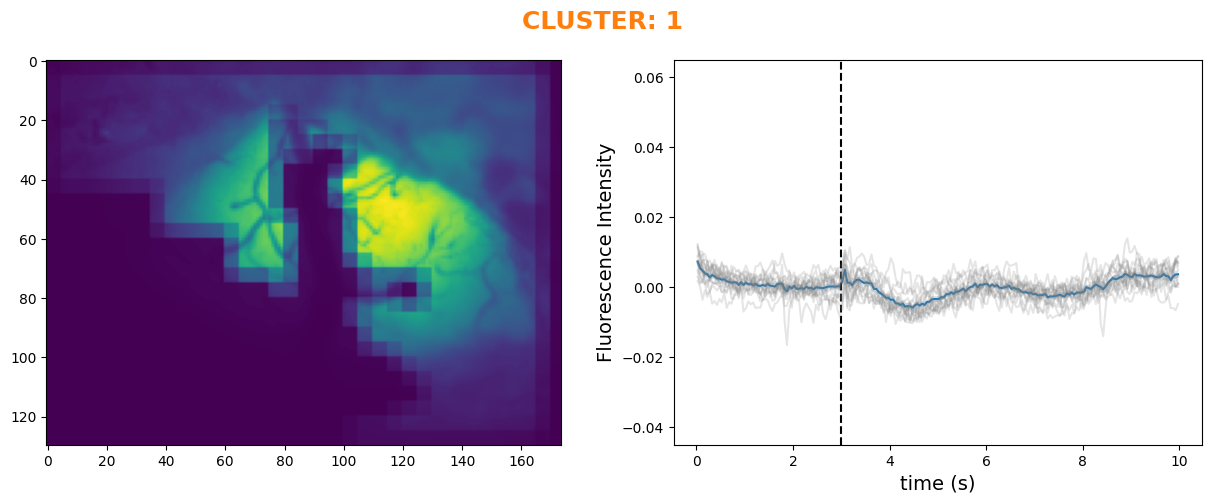

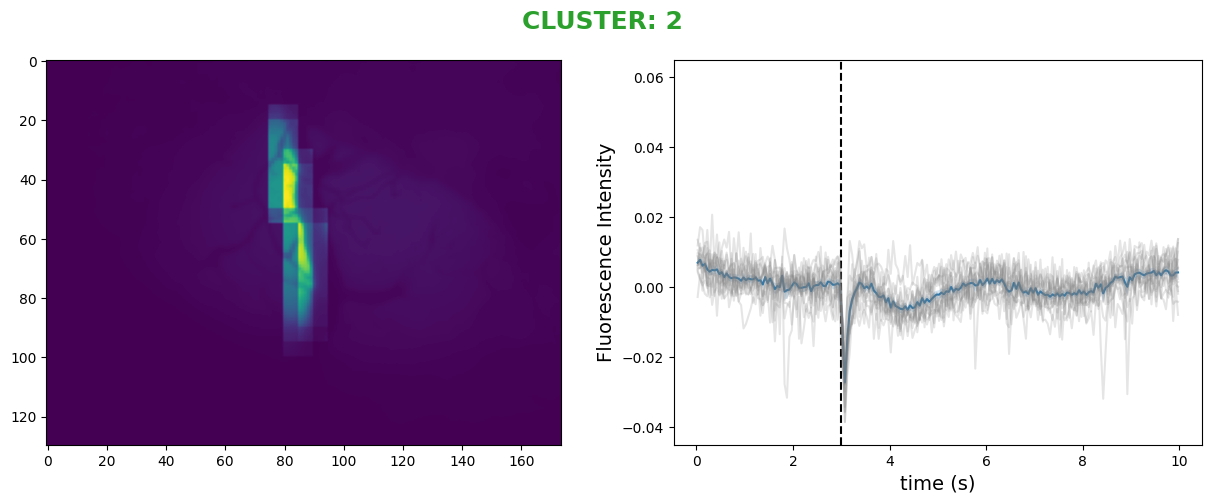

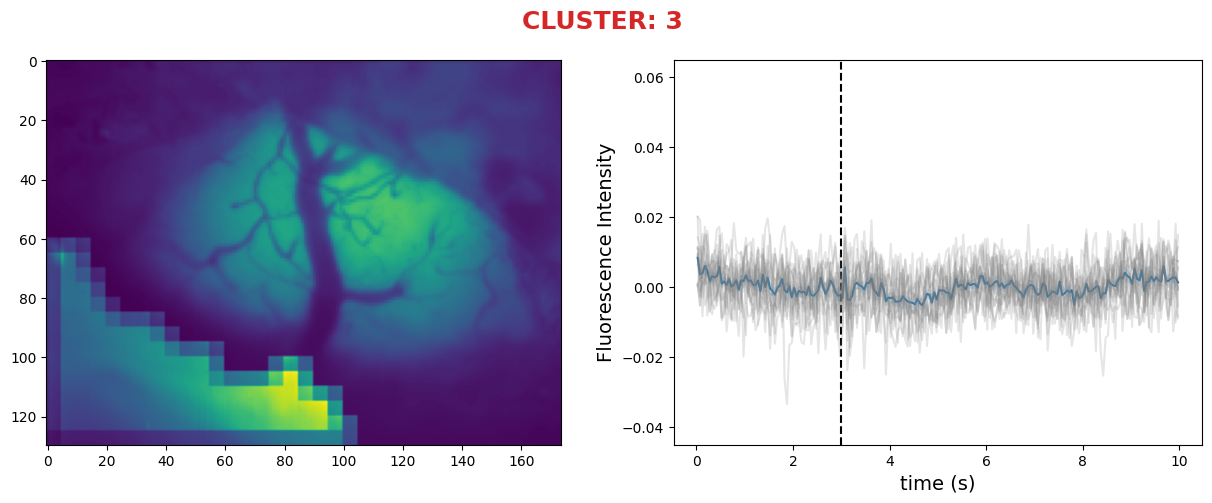

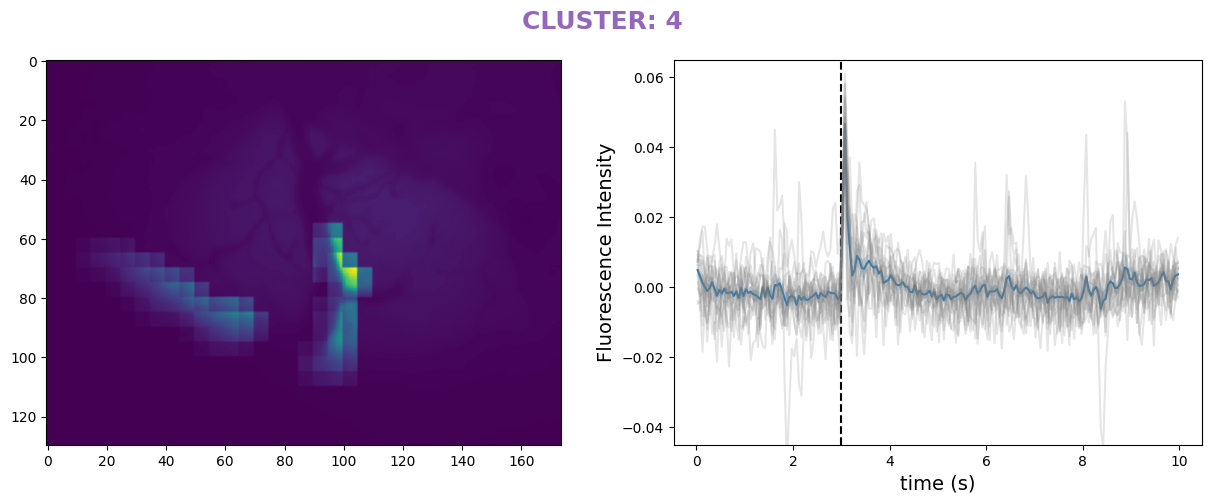

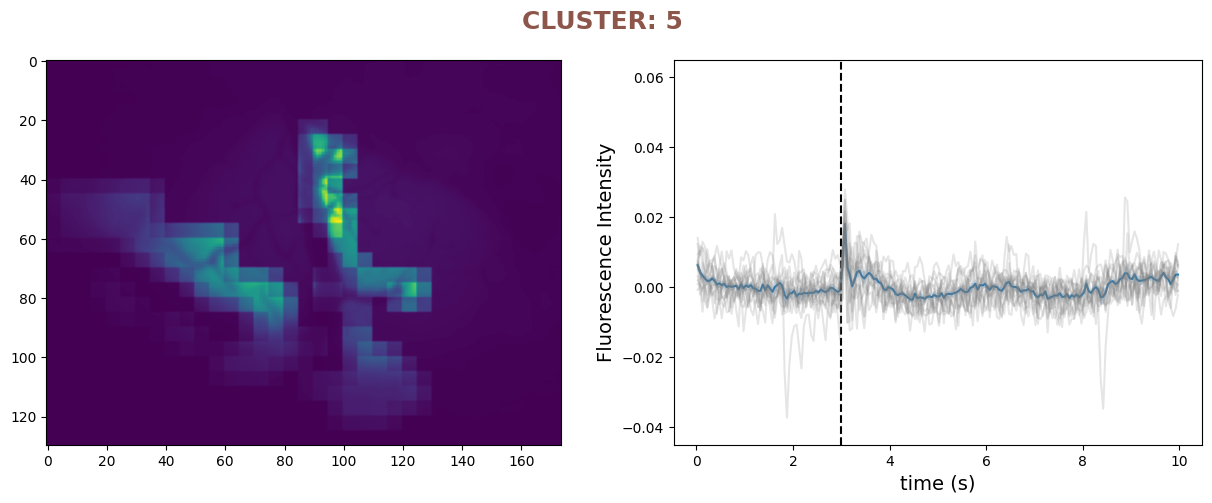

In [154]:
# Plot average fluorescence traces in each cluster and corresponding ROIs
plotting.plot_cluster_roi(img_series, masks, roi_avg_filt, color_map, leaves_color_list, leaf_order, 
                          Yaxis_range=(-0.045, 0.065), plot_errBar=True, plot_traces=True)